In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from distmetrics import compute_mahalonobis_dist_2d, get_asf_rtc_burst_ts, read_asf_rtc_image_data, despeckle_rtc_arrs_with_tv
import matplotlib.pyplot as plt
from rasterio.plot import show
import numpy as np
from scipy.special import expit, logit
from distmetrics import load_trained_transformer_model, compute_transformer_zscore


References:

- CNN story: https://www.cnn.com/2024/05/25/world/video/damage-papua-new-guinea-landslide-ldn-digvid
- ASF Search: https://search.asf.alaska.edu/#/?polygon=POINT(143.3641%20-5.3821)&zoom=13.000&center=143.364,-5.425&resultsLoaded=true&granule=OPERA_L2_RTC-S1_T009-019294-IW2_20240603T084748Z_20240603T133726Z_S1A_30_v1.0&maxResults=250&dataset=OPERA-S1&productTypes=RTC

In [3]:
BURST_ID = 'T009_019294_IW2'

In [4]:
df_rtc_ts = get_asf_rtc_burst_ts(BURST_ID)
print('# of results: ', df_rtc_ts.shape[0])
df_rtc_ts.head()

# of results:  31


,opera_id,acq_datetime,polarization,url_vh,url_vv,track_number,geometry,dedup_id
0,OPERA_L2_RTC-S1_T009-019294-IW2_20231007T08475...,2023-10-07 08:47:51+00:00,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,9,"POLYGON ((143.32562 -5.40839, 143.3687 -5.3988...",OPERA_L2_RTC-S1_T009-019294-IW2_20231007T084751Z
1,OPERA_L2_RTC-S1_T009-019294-IW2_20231019T08475...,2023-10-19 08:47:51+00:00,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,9,"POLYGON ((143.32543 -5.40847, 143.36851 -5.398...",OPERA_L2_RTC-S1_T009-019294-IW2_20231019T084751Z
2,OPERA_L2_RTC-S1_T009-019294-IW2_20231031T08475...,2023-10-31 08:47:51+00:00,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,9,"POLYGON ((143.32647 -5.40917, 144.11392 -5.234...",OPERA_L2_RTC-S1_T009-019294-IW2_20231031T084751Z
3,OPERA_L2_RTC-S1_T009-019294-IW2_20231112T08475...,2023-11-12 08:47:51+00:00,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,9,"POLYGON ((143.32594 -5.40897, 144.11342 -5.234...",OPERA_L2_RTC-S1_T009-019294-IW2_20231112T084751Z
4,OPERA_L2_RTC-S1_T009-019294-IW2_20231124T08475...,2023-11-24 08:47:50+00:00,VV+VH,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,https://datapool.asf.alaska.edu/RTC/OPERA-S1/O...,9,"POLYGON ((143.32749 -5.40822, 144.11495 -5.233...",OPERA_L2_RTC-S1_T009-019294-IW2_20231124T084750Z


**Warning**: sometime this cell fails and must be re-run due to a transient server error.

In [6]:
arrs_vv, profiles = read_asf_rtc_image_data(df_rtc_ts.url_vv.tolist())
arrs_vh, _ = read_asf_rtc_image_data(df_rtc_ts.url_vh.tolist())

Loading RTC data: 100%|█████████████████████████| 31/31 [00:26<00:00,  1.19it/s]


In [7]:
arrs_vv_d = despeckle_rtc_arrs_with_tv(arrs_vv)
arrs_vh_d = despeckle_rtc_arrs_with_tv(arrs_vh)

100%|███████████████████████████████████████████| 31/31 [00:09<00:00,  7.30it/s]


In [8]:
for k, date in enumerate(df_rtc_ts.acq_datetime):
    print(k, date)

0 2023-10-07 08:47:51+00:00
1 2023-10-19 08:47:51+00:00
2 2023-10-31 08:47:51+00:00
3 2023-11-12 08:47:51+00:00
4 2023-11-24 08:47:50+00:00
5 2023-12-06 08:47:50+00:00
6 2023-12-18 08:47:49+00:00
7 2023-12-30 08:47:49+00:00
8 2024-01-11 08:47:48+00:00
9 2024-01-23 08:47:48+00:00
10 2024-02-04 08:47:47+00:00
11 2024-02-16 08:47:47+00:00
12 2024-02-28 08:47:47+00:00
13 2024-03-11 08:47:47+00:00
14 2024-03-23 08:47:48+00:00
15 2024-04-04 08:47:48+00:00
16 2024-04-16 08:47:48+00:00
17 2024-04-28 08:47:49+00:00
18 2024-05-22 08:47:48+00:00
19 2024-06-03 08:47:48+00:00
20 2024-06-15 08:47:48+00:00
21 2024-06-27 08:47:47+00:00
22 2024-07-09 08:47:47+00:00
23 2024-07-21 08:47:46+00:00
24 2024-08-02 08:47:46+00:00
25 2024-08-14 08:47:46+00:00
26 2024-08-26 08:47:46+00:00
27 2024-09-07 08:47:47+00:00
28 2024-09-19 08:47:47+00:00
29 2024-10-01 08:47:47+00:00
30 2024-10-13 08:47:48+00:00


In [13]:
pre_slice = slice(9, 19) # excludes last index
post_index = 19

In [14]:
transformer = load_trained_transformer_model()

In [15]:
pre_imgs_vv = arrs_vv_d[pre_slice]

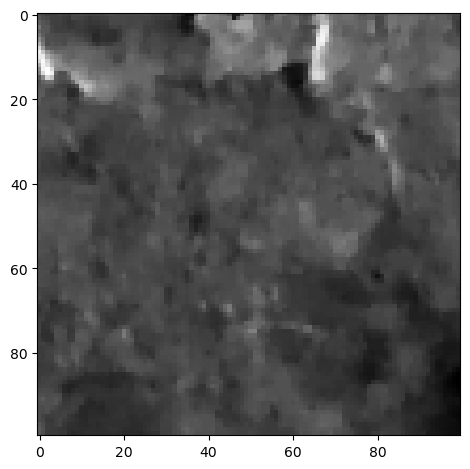

In [151]:
sy = np.s_[1325:1425]
sx = np.s_[530:630]
plt.imshow(pre_imgs_vv[0][sy, sx], cmap='binary_r', interpolation='none')
#plt.axis('off')
plt.tight_layout()

In [152]:
pre_vv_c = [arr[sy, sx] for arr in arrs_vv_d[pre_slice]]
pre_vh_c = [arr[sy, sx] for arr in arrs_vh_d[pre_slice]]

post_vv_c = arrs_vv_d[post_index][sy, sx]
post_vh_c = arrs_vh_d[post_index][sy, sx]

In [153]:
from pathlib import Path

landslide_png_dir_latex = Path('landslide_latex_ts')
landslide_png_dir_latex.mkdir(exist_ok=True)

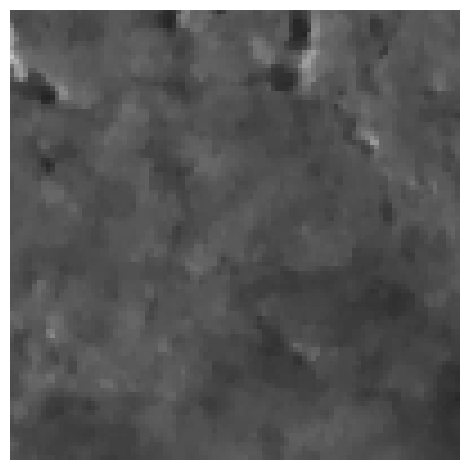

In [154]:
for k, (vv, vh) in enumerate(zip(pre_vv_c, pre_vh_c)):
    plt.imshow(vv, cmap='binary_r', vmin=0, vmax=.5)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(landslide_png_dir_latex / f'landslide-vv-{k}.png', bbox_inches = 'tight', pad_inches = 0)

    plt.imshow(vh, cmap='binary_r', vmin=0, vmax=.15)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(landslide_png_dir_latex / f'landslide-vh-{k}.png', bbox_inches = 'tight', pad_inches = 0)
 

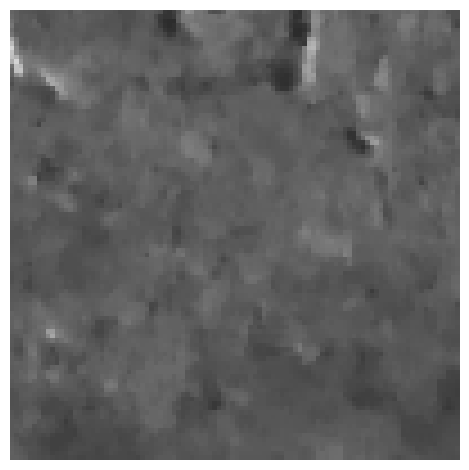

In [155]:
n = len(pre_imgs_vv)
for _, (vv, vh) in enumerate(zip([post_vv_c], [post_vh_c])):
    plt.imshow(vv, cmap='binary_r', vmin=0, vmax=.5)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(landslide_png_dir_latex / f'landslide-vv-{n}.png', bbox_inches = 'tight', pad_inches = 0)

    plt.imshow(vh, cmap='binary_r', vmin=0, vmax=.15)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(landslide_png_dir_latex / f'landslide-vh-{n}.png', bbox_inches = 'tight', pad_inches = 0)
 

In [156]:
dist_ob = compute_transformer_zscore(transformer, 
                                     pre_vv_c,
                                     pre_vh_c,
                                     post_vv_c,
                                     post_vh_c,
                                     stride=2,
                                     agg='max',
                                     batch_size=256,
                                     memory_strategy='high')

Chips Traversed: 100%|████████████████████████████| 8/8 [00:00<00:00, 18.21it/s]


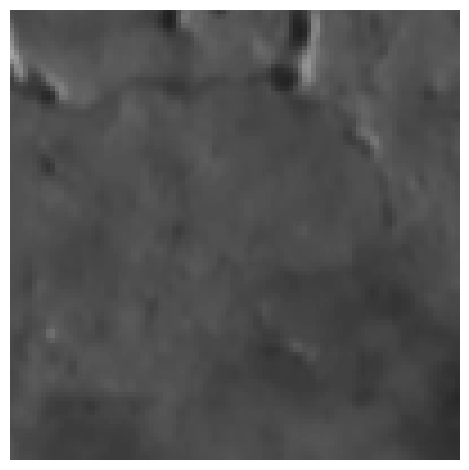

In [172]:
from scipy.special import logit, expit
for (k, token) in zip([0, 1], ['vv', 'vh']):
    vmax = .5 if k == 0 else .15
    plt.imshow(expit(dist_ob.mean[k, ...]), cmap='binary_r', vmin=0, vmax=vmax)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(landslide_png_dir_latex / f'landslide-mean-{token}.png', bbox_inches = 'tight', pad_inches = 0)


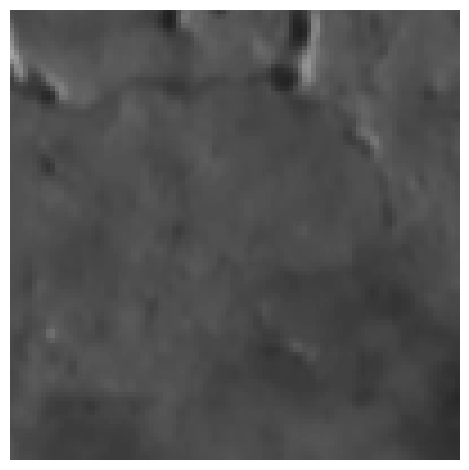

In [196]:
from scipy.special import logit, expit
for (k, token) in zip([0, 1], ['vv', 'vh']):
    vmax = .5 if k == 0 else .15
    plt.imshow(expit(dist_ob.mean[k, ...]), cmap='binary_r', vmin=0, vmax=vmax)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(landslide_png_dir_latex / f'landslide-mean-{token}.png', bbox_inches = 'tight', pad_inches = 0)


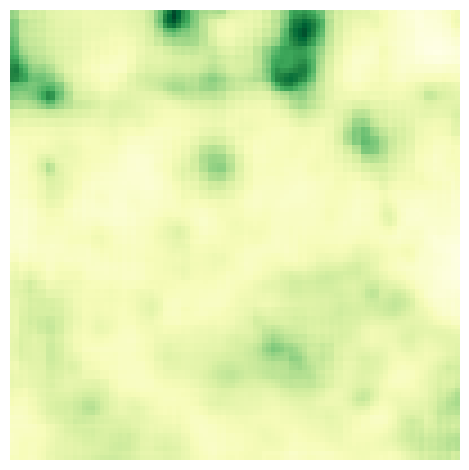

In [197]:
for (k, token) in zip([0, 1], ['vv', 'vh']):
    plt.imshow(expit(dist_ob.std[k, ...]), cmap='YlGn')
    plt.axis('off')
    plt.tight_layout()

    plt.savefig(landslide_png_dir_latex / f'landslide-std-{token}.png', bbox_inches = 'tight', pad_inches = 0)


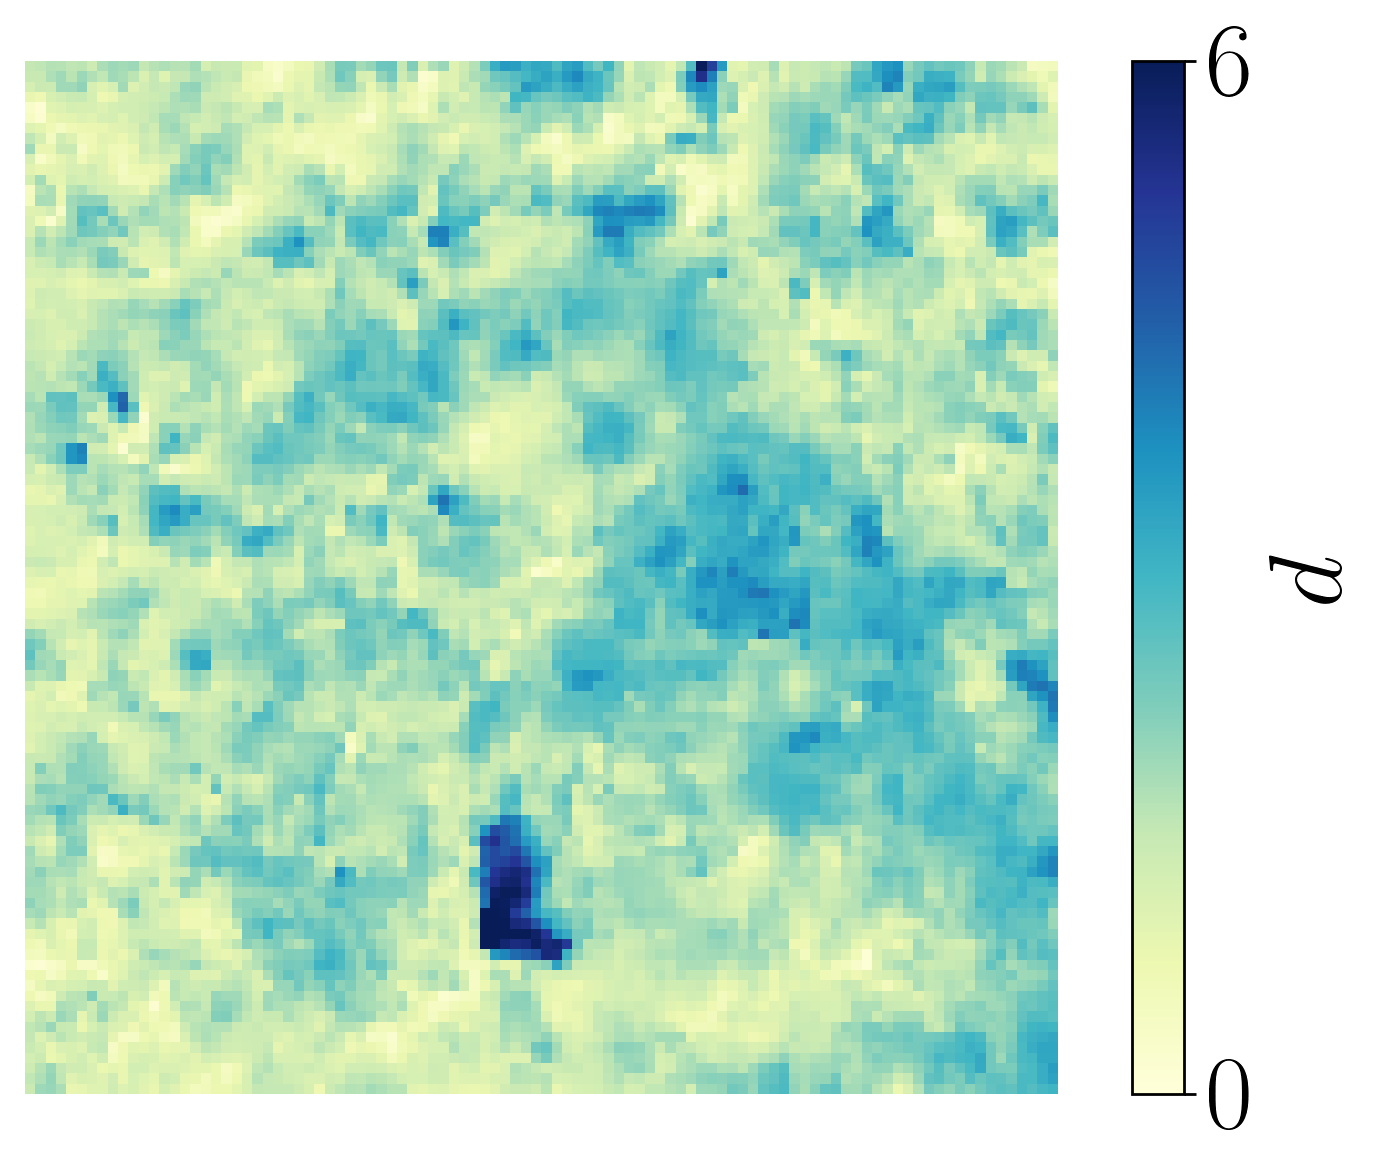

In [199]:
fig, ax = plt.subplots(dpi=250)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",  # Use a serif font
    "font.serif": ["Times New Roman"],  # Specify the serif font
})

im = ax.imshow((dist_ob.dist), cmap='YlGnBu', interpolation='none', vmin=0, vmax=6)
ax.axis('off')

cbar = fig.colorbar(im, shrink=1)
cbar.set_ticks([0, 6])
cbar.set_ticklabels(['0',  '$6$'], fontsize=30)
cbar.ax.set_ylabel('$d$', fontsize=30)
plt.tight_layout()

plt.savefig(landslide_png_dir_latex / f'landslide-metric.png', bbox_inches = 'tight', pad_inches = 0)